In [42]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [43]:
wm = 1.0
tlist = np.linspace(0, 200, 400)
disorder = 0.2
args = {"A": 0.1}
Rtau_all = []
N = 6

In [44]:
qH0, qH1_list, wm = get_random_freq_qubit_ham(N)
eigenvalues, eigenstates = qH0.eigenstates()
Rtau_qubit = []
for _ in range(50):
    dw = np.random.uniform(-disorder, disorder, N)
    omega_list = wm + dw
    H = [qH0]

    for r in range(N):
        args[f"wd{r}"] = omega_list[r]
        H.append([qH1_list[r], make_coeff(r)])

    H = qt.QobjEvo(H, args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[qH0])
    Rtau_qubit.append(np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])))
Rtau_qubit = np.array(Rtau_qubit)
Rtau_all.append(np.mean(Rtau_qubit, axis=0))

In [45]:
wd = 0.642570281124498
H0, H1_list, eigenvalues, eigenstates, psi0, basisList = get_random_freq_scar_ham(N)

Rtau_scar = []
for _ in range(50):
    dw = np.random.uniform(-disorder, disorder, N)
    omega_list = wd + dw
    H = [H0]

    for r in range(N):
        args[f"wd{r}"] = omega_list[r]
        H.append([H1_list[r], make_coeff(r)])

    H = qt.QobjEvo(H, args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar.append(np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])))
Rtau_scar = np.array(Rtau_scar)
Rtau_all.append(np.mean(Rtau_scar, axis=0))

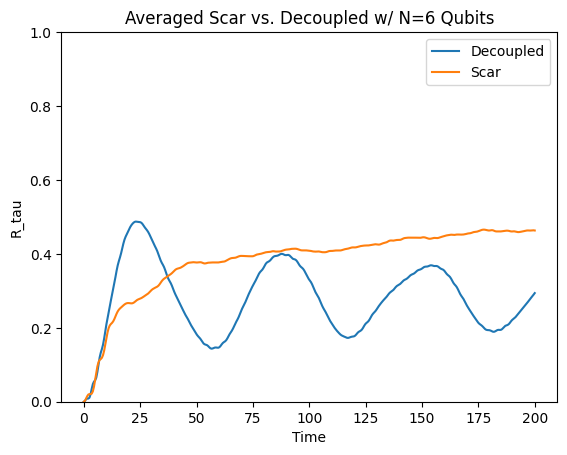

In [46]:
plt.plot(tlist, Rtau_all[0], label="Decoupled")
plt.plot(tlist, Rtau_all[1], label="Scar")
plt.title(f"Averaged Scar vs. Decoupled w/ N={N} Qubits")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.legend()
plt.show()